In [28]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official')
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a_init, b = load_and_rotate(rotation='varimax')

a_df = pd.DataFrame(a_init, index=resmat.columns)

/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 19)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 19)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.36679121 -1.29142072  0.02368664 ...  0.5948743   1.20452549
  -1.32143699]
 [ 0.8694796   0.65897874 -2.01923406 ... -0.49557078  1.18055759
  -1.37415132]
 [ 1.82481648 -1.4122685  -0.51204663 ...  0.78741921 -0.97111116
  -1.49879246]
 ...
 [-0.9912067  -0.93205986 -0.40201418 ...  0.99411487 -0.17602767
   1.24166521]
 [-0.71577314 -0.59205097 -0.52410342 ...  1.13348854 -0.10466067
   0.66230223]
 [ 0.18720646 -0.9709694   0.55470963 ...  0.3900838   1.68143397
  -0.28299898]]


In [29]:
# drop all rows where the index contains math scenario in get_level_values(0)
math_dataset = a_df.loc[a_df.index.get_level_values('scenario').str.contains('math')]
math = math_dataset.to_numpy()

436 436 19
[INFO] n_items=436 <= sample_size. Using all items.
[INFO] Computing pairwise dot products (this will produce a symmetric matrix of size n_work x n_work)...
[INFO] Converting square distance matrix to condensed form for clustering...
[INFO] Computing Ward linkage...
[INFO] Plotting dendrogram...


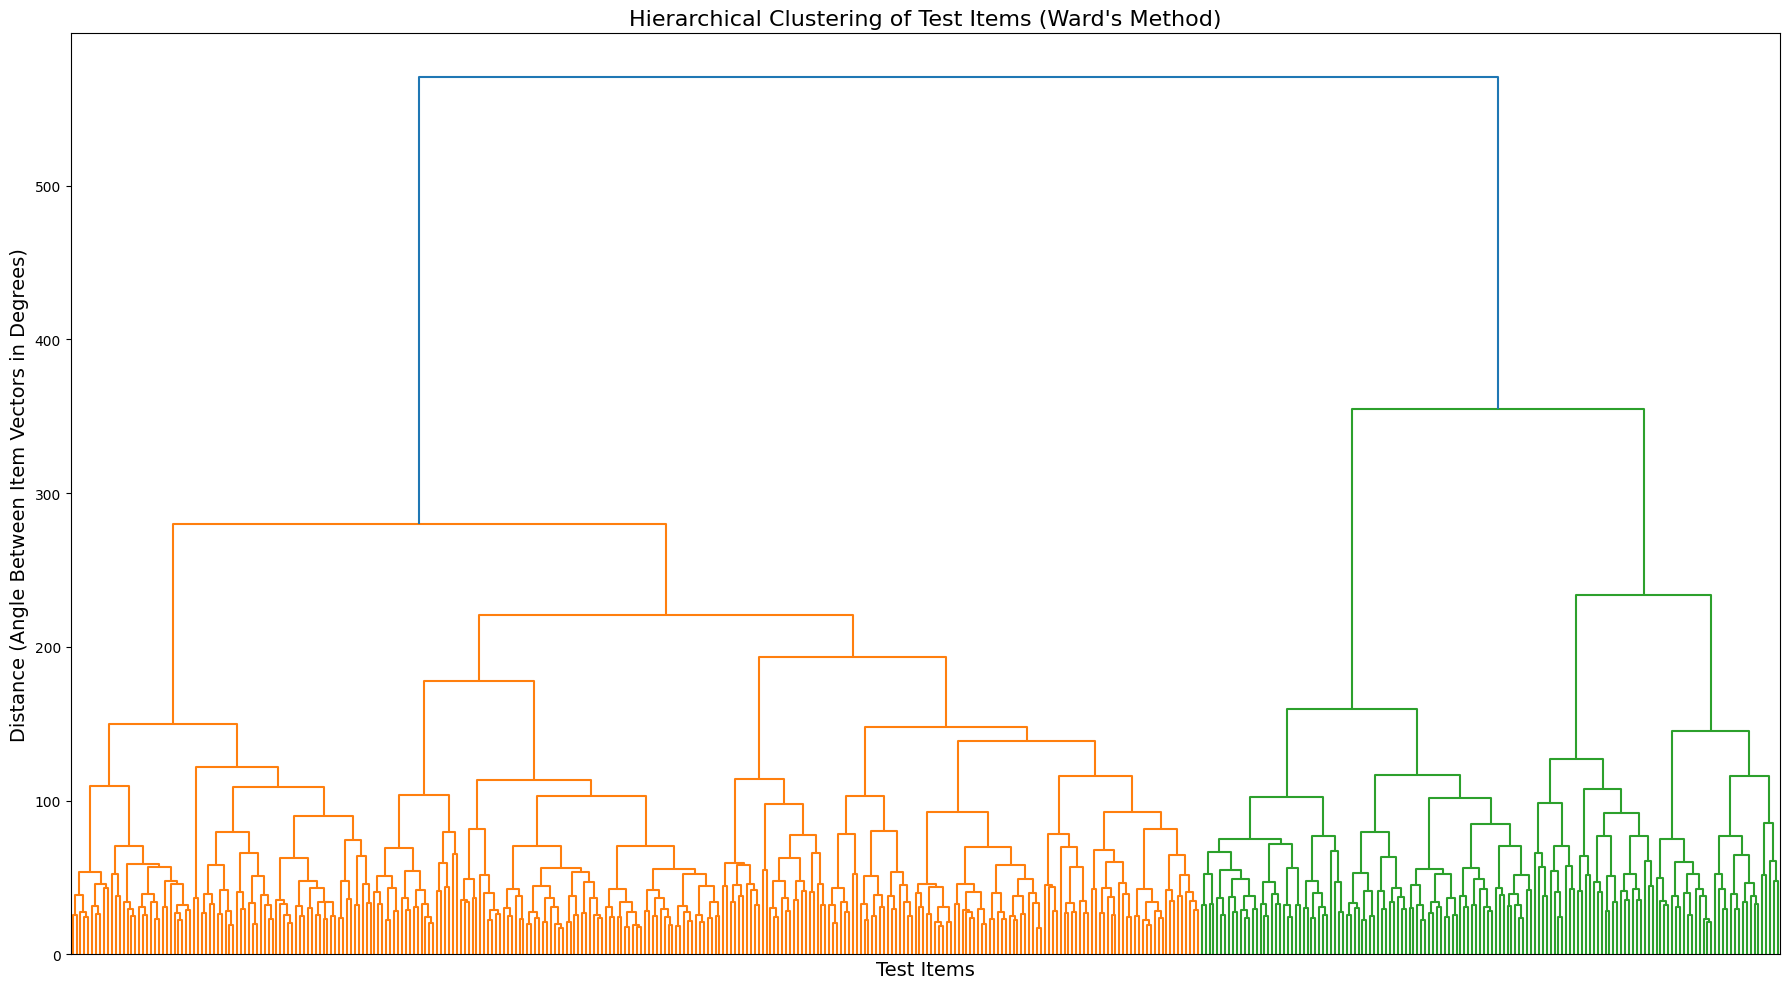

[DONE] Dendrogram displayed.


In [30]:
# hierarchical_mirt_clustering.py
"""
Hierarchical clustering of MIRT item discrimination vectors (a-matrix).
Inputs expected to be pre-loaded in the environment:
    - a : numpy.ndarray, shape (n_items, n_dimensions)
    - model_names : list of str, length n_items

Procedure:
  Step 1: compute direction cosines (normalize each item vector)
  Step 2: compute pairwise angle matrix (degrees) between item vectors
  Step 3: perform hierarchical clustering using Ward's method
  Step 4: plot dendrogram (Ward linkage)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import ward, dendrogram

# ----------------------------
# Parameters / user-tunable
# ----------------------------
sample_size = 2000            # threshold: if n_items > sample_size, randomly sample down to this
random_seed = 42              # reproducible sampling
show_leaf_labels = False       # whether to show labels on x-axis (can be noisy for large samples)
leaf_label_rotation = 90      # rotate x labels if needed
model_names = math_dataset.loc[math_dataset.index.get_level_values('scenario').str.contains('math')].index.get_level_values('input.text').tolist()
a = math

n_items, n_dims = a.shape
print(len(model_names), n_items, n_dims)
if len(model_names) != n_items:
    raise ValueError("Length of `model_names` must match number of rows in `a`.")

if n_items < 2:
    raise ValueError("At least two items are required for clustering.")

# ----------------------------
# Step 0: (Optional) sampling for large datasets
# ----------------------------
rng = np.random.default_rng(random_seed)
if n_items > sample_size:
    print(f"[INFO] n_items={n_items} > sample_size={sample_size}. Sampling {sample_size} items for analysis.")
    sampled_idx = rng.choice(n_items, size=sample_size, replace=False)
    a_work = a[sampled_idx, :].astype(float)
    model_names_work = [model_names[i] for i in sampled_idx]
else:
    print(f"[INFO] n_items={n_items} <= sample_size. Using all items.")
    a_work = a.astype(float)
    model_names_work = list(model_names)

n_work = a_work.shape[0]

# ----------------------------
# Step 1: Calculate Direction Cosines (unit vectors)
# ----------------------------
# Normalize each row vector to unit length. Handle zero-norm rows by leaving them as zero vectors.
# cos(α_il) = a_il / sqrt(sum_k a_ik^2)
row_norms = np.linalg.norm(a_work, axis=1, keepdims=True)  # shape (n_work, 1)
# Avoid division by zero: where norm == 0, set norm to 1 temporarily and then set row to zeros afterwards
zero_norm_mask = (row_norms.squeeze() == 0)
safe_row_norms = row_norms.copy()
safe_row_norms[zero_norm_mask, 0] = 1.0
direction_cosines = a_work / safe_row_norms  # shape (n_work, n_dims)
# Explicitly set zero-norm rows to all-zero direction cosine vectors
if np.any(zero_norm_mask):
    direction_cosines[zero_norm_mask, :] = 0.0
    print(f"[WARN] {zero_norm_mask.sum()} item(s) had zero-length discrimination vectors and were set to zero direction cosines.")

# ----------------------------
# Step 2: Compute Pairwise Angle Matrix (in degrees)
# ----------------------------
# For unit vectors u and v: angle = arccos( dot(u, v) )
# Compute dot-product matrix efficiently, then clip to [-1, 1], arccos, convert to degrees.
print("[INFO] Computing pairwise dot products (this will produce a symmetric matrix of size n_work x n_work)...")
dot_product_matrix = np.dot(direction_cosines, direction_cosines.T)  # shape (n_work, n_work)

# Numerical safety: clip to [-1, 1]
np.clip(dot_product_matrix, -1.0, 1.0, out=dot_product_matrix)

# Compute angles in radians then convert to degrees
angle_matrix_rad = np.arccos(dot_product_matrix)
angle_matrix_deg = np.degrees(angle_matrix_rad)  # this is the distance matrix to use

# Ensure diagonal zeros (should be 0 but numeric rounding might give tiny values)
np.fill_diagonal(angle_matrix_deg, 0.0)

# ----------------------------
# Step 3: Perform Hierarchical Clustering (Ward's method)
# ----------------------------
# ward() expects a condensed distance matrix (1-D) as input. Convert with squareform.
print("[INFO] Converting square distance matrix to condensed form for clustering...")
condensed_dist = squareform(angle_matrix_deg, checks=True)  # will raise if shape invalid

print("[INFO] Computing Ward linkage...")
linkage = ward(condensed_dist)  # returns linkage matrix

# ----------------------------
# Step 4: Visualize the Results (Dendrogram)
# ----------------------------
print("[INFO] Plotting dendrogram...")
plt.figure(figsize=(18, 10))
dendro_kwargs = {
    'linkage': linkage,
    # Provide labels for leaves; dendrogram will use them in order of the leaves
    'labels': model_names_work if show_leaf_labels else None,
    'leaf_rotation': leaf_label_rotation,
    'leaf_font_size': 8 if n_work <= 2000 else 6,  # try to keep labels readable; user can adjust
    'color_threshold': None,  # show colored clusters by default thresholding (optional)
}

# SciPy dendrogram API expects inputs slightly differently; pass linkage matrix and labels via parameters
dend = dendrogram(linkage, labels=dendro_kwargs['labels'],
                  leaf_rotation=dendro_kwargs['leaf_rotation'],
                  leaf_font_size=dendro_kwargs['leaf_font_size'],
                  color_threshold=dendro_kwargs['color_threshold'])

plt.title("Hierarchical Clustering of Test Items (Ward's Method)", fontsize=16)
plt.ylabel("Distance (Angle Between Item Vectors in Degrees)", fontsize=14)
plt.xlabel("Test Items", fontsize=14)

# If labels are too crowded, you may want to hide them: user requested rotation if needed (done above).
if not show_leaf_labels:
    plt.xticks([])

plt.tight_layout()
plt.show()

print("[DONE] Dendrogram displayed.")


In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import fcluster

# --- Inputs from your previous script ---
# These variables should already exist in your environment.
# linkage: The linkage matrix from the ward() function.
# model_names_work: The list of item names used in the clustering.
# a_work: The sampled a-matrix used in the clustering.
# ----------------------------------------


## Step 1: Extract Cluster Assignments from the Linkage Matrix
# You need to decide how many clusters to extract.
# Look at your dendrogram plot and choose a number that corresponds to the
# main, distinct, color-coded branches. For your previous plot, 4 was a good choice.
num_clusters_to_extract = 4  # <-- YOUR INPUT HERE

# The fcluster function takes the linkage matrix and assigns a cluster ID (from 1 to k) to each item.
empirical_cluster_labels = fcluster(linkage, t=num_clusters_to_extract, criterion='maxclust')


## Step 2: Combine Results into a DataFrame for Analysis
# This DataFrame is your primary tool for investigating the clusters.
results_df = pd.DataFrame({
    'item_text': model_names_work,
    'cluster_id': empirical_cluster_labels,
    'a_vector': list(a_work)  # Store the a-vector for each item
})

print(f"Successfully assigned {len(results_df)} items to {num_clusters_to_extract} clusters.")


## Step 3: Analyze the Content of Each Cluster
# This loop will print a summary and sample items for each cluster you've identified.
# This is where you apply your subject-matter expertise to understand what each cluster represents.

for i in range(1, num_clusters_to_extract + 1):
    # Filter the DataFrame for the current cluster
    cluster_df = results_df[results_df['cluster_id'] == i]
    
    print("\n" + "="*60)
    print(f"ANALYSIS OF CLUSTER {i} ({len(cluster_df)} items)")
    print("="*60)
    
    # --- Content Analysis ---
    print("\nSample of 5 items from this cluster:")
    # Use display() if in a notebook for better formatting, otherwise print() is fine.
    pd.set_option('display.max_colwidth', None)
    display(cluster_df[['item_text']].head())
    
    # --- Quantitative Analysis ---
    # Calculate the average discrimination vector (centroid) for this cluster.
    # This shows the quantitative "profile" of the skill measured by this cluster.
    cluster_centroid = np.mean(np.vstack(cluster_df['a_vector'].values), axis=0)
    print(f"\nAverage Discrimination Profile (Centroid) for Cluster {i}:")
    # Create a labeled series for easier interpretation
    centroid_series = pd.Series(cluster_centroid, index=[f'F{j+1}' for j in range(len(cluster_centroid))])
    print(centroid_series.round(2))

In [34]:
a_df.index

MultiIndex([(                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import svd

# Assume a_df is your (78712 x 19) item discrimination matrix
# Rows = items, Columns = dimensions

# Normalize each item vector (so only orientation matters, not magnitude)
a_norm = normalize(a_df.values, axis=1)
a_norm_df = pd.DataFrame(a_norm, index=a_df.index, columns=a_df.columns)

# ---------------------------------------------------------------------
# 1. Convergent validity: alignment of items with their reference composite
# ---------------------------------------------------------------------

def reference_composite(a_sub):
    """Compute the dominant eigenvector (reference composite) for a construct."""
    # SVD is stable: first right singular vector = principal component
    _, _, vh = svd(a_sub, full_matrices=False)
    return vh[0]

# If your index is MultiIndex and "scenario" is one of the levels:
scenarios = a_df.index.get_level_values("scenario").unique()

construct_map = {}
for scen in scenarios:
    construct_map[scen] = a_df.index[a_df.index.get_level_values("scenario") == scen].tolist()

print("Number of items per scenario:")
print({k: len(v) for k, v in construct_map.items()})

convergent_results = {}

for construct, items in construct_map.items():
    sub = a_norm_df.loc[items].values
    comp = reference_composite(sub)

    # Compute cosine similarity (alignment) of each item to composite
    sims = sub @ comp / (np.linalg.norm(comp) + 1e-9)
    convergent_results[construct] = sims.mean()  # average alignment

convergent_df = pd.DataFrame.from_dict(convergent_results, orient="index", columns=["AvgAlignment"])
print("\nConvergent validity (avg cosine similarity to reference composite):")
print(convergent_df)

# ---------------------------------------------------------------------
# 2. Divergent validity: separation between constructs
# ---------------------------------------------------------------------

divergent_results = {}

construct_vectors = {}
for construct, items in construct_map.items():
    sub = a_norm_df.loc[items].values
    construct_vectors[construct] = reference_composite(sub)

constructs = list(construct_vectors.keys())

for i in range(len(constructs)):
    for j in range(i + 1, len(constructs)):
        c1, c2 = constructs[i], constructs[j]
        v1, v2 = construct_vectors[c1], construct_vectors[c2]
        cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        divergent_results[(c1, c2)] = cos_sim

# Convert tuple-index Series to a nice DataFrame
divergent_series = pd.Series(divergent_results)
divergent_series.index = pd.MultiIndex.from_tuples(divergent_series.index, names=["Construct1", "Construct2"])
divergent_df = divergent_series.unstack()

print("\nDivergent validity (cosine similarity between constructs):")
print(divergent_df.round(3).fillna(""))



Number of items per scenario:
{'lsat_qa': 454, 'truthful_qa': 1888, 'synthetic_reasoning': 2234, 'babi_qa': 3461, 'wikifact': 5511, 'bbq': 999, 'thai_exam': 557, 'dyck_language_np=3': 500, 'legal_support': 594, 'civil_comments': 29407, 'legalbench': 1997, 'raft': 1336, 'air_bench_2024': 4985, 'math': 436, 'med_qa': 998, 'gsm': 997, 'boolq': 3316, 'mmlu': 13223, 'entity_matching': 1396, 'entity_data_imputation': 395, 'commonsense': 498, 'imdb': 3530}

Convergent validity (avg cosine similarity to reference composite):
                        AvgAlignment
lsat_qa                    -0.431749
truthful_qa                -0.432941
synthetic_reasoning         0.529086
babi_qa                     0.318962
wikifact                    0.332570
bbq                        -0.292932
thai_exam                  -0.167220
dyck_language_np=3          0.288009
legal_support               0.030375
civil_comments              0.390499
legalbench                  0.178251
raft                       -0.263

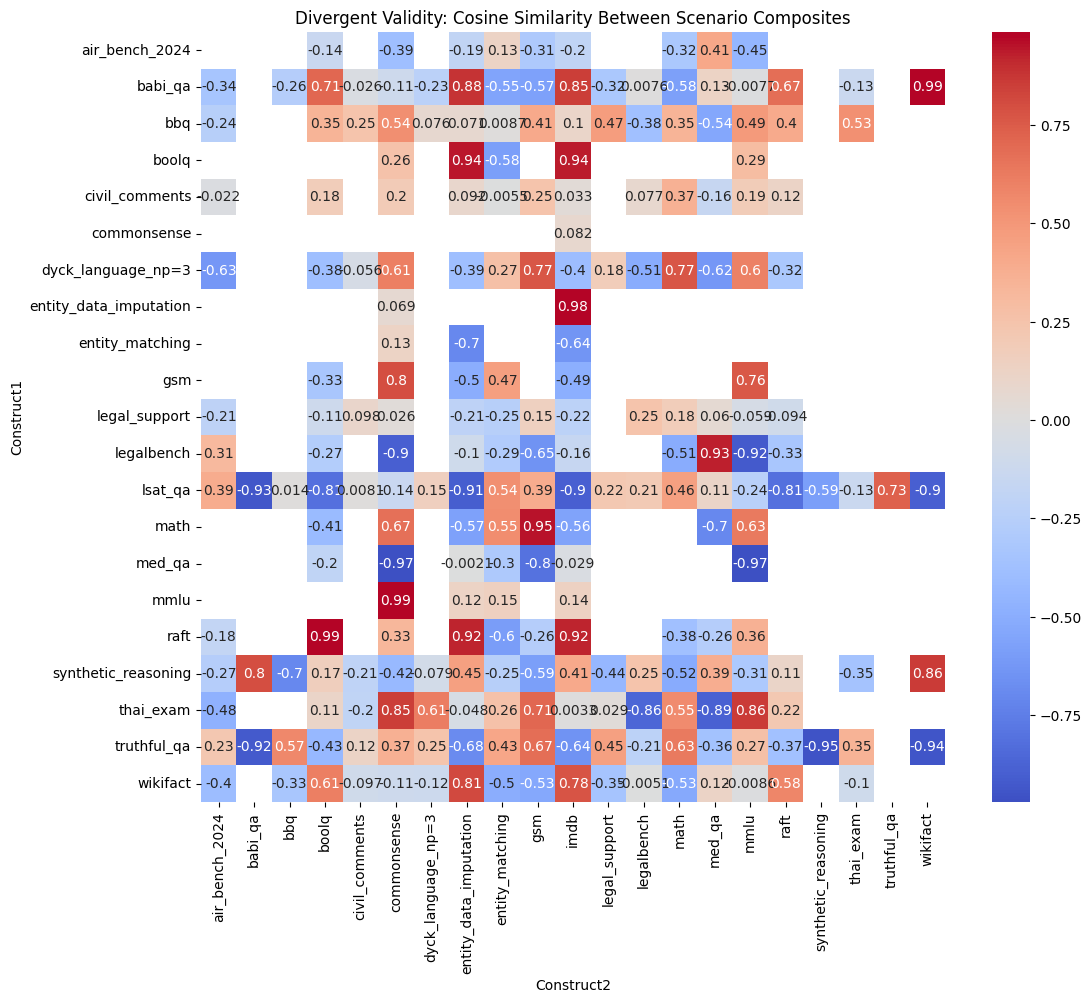

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(divergent_df.astype(float), cmap="coolwarm", center=0, annot=True)
plt.title("Divergent Validity: Cosine Similarity Between Scenario Composites")
plt.show()


In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from scipy.linalg import svd

# ================================================================
# Utilities
# ================================================================

def reference_composite(a_sub):
    """Compute dominant eigenvector (reference composite) for a scenario."""
    _, _, vh = svd(a_sub, full_matrices=False)
    return vh[0]

def evaluate_validity(a_df, scenarios_to_check):
    """
    Evaluate convergent + divergent validity for a given subset of scenarios.
    
    Parameters:
        a_df (pd.DataFrame): (items x dimensions) discrimination matrix
        scenarios_to_check (list): list of scenario names to evaluate
    
    Returns:
        convergent_df (pd.DataFrame): average alignment per scenario
        divergent_df (pd.DataFrame): cosine similarity between scenarios
    """
    # Normalize item vectors
    a_norm = normalize(a_df.values, axis=1)
    a_norm_df = pd.DataFrame(a_norm, index=a_df.index, columns=a_df.columns)

    # Build construct_map
    construct_map = {}
    for scen in scenarios_to_check:
        construct_map[scen] = a_df.index[a_df.index.get_level_values("scenario") == scen].tolist()

    # -----------------------------------------------------------------
    # Convergent validity
    # -----------------------------------------------------------------
    convergent_results = {}
    construct_vectors = {}

    for scen, items in construct_map.items():
        sub = a_norm_df.loc[items].values
        comp = reference_composite(sub)

        # Save reference composite for later
        construct_vectors[scen] = comp

        # Compute cosine similarity item -> composite
        sims = sub @ comp / (np.linalg.norm(comp) + 1e-9)
        convergent_results[scen] = sims.mean()

    convergent_df = pd.DataFrame.from_dict(convergent_results, orient="index", columns=["AvgAlignment"])

    # -----------------------------------------------------------------
    # Divergent validity
    # -----------------------------------------------------------------
    divergent_results = {}
    scenarios = list(construct_vectors.keys())

    for i in range(len(scenarios)):
        for j in range(i + 1, len(scenarios)):
            s1, s2 = scenarios[i], scenarios[j]
            v1, v2 = construct_vectors[s1], construct_vectors[s2]
            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
            divergent_results[(s1, s2)] = cos_sim

    divergent_series = pd.Series(divergent_results)
    divergent_series.index = pd.MultiIndex.from_tuples(divergent_series.index, names=["Scenario1", "Scenario2"])
    divergent_df = divergent_series.unstack()

    return convergent_df, divergent_df

# ================================================================
# Example usage
# ================================================================

# Pick any subset of scenarios to evaluate
scenarios_to_check = ["math", "wikifact", "civil_comments", 'gsm']

convergent_df, divergent_df = evaluate_validity(a_df, scenarios_to_check)

print("\nConvergent validity (avg cosine similarity to reference composite):")
print(convergent_df.round(3))

print("\nDivergent validity (cosine similarity between constructs):")
print(divergent_df.round(3).fillna(""))



Convergent validity (avg cosine similarity to reference composite):
                AvgAlignment
math                  -0.680
wikifact               0.333
civil_comments         0.390
gsm                   -0.703

Divergent validity (cosine similarity between constructs):
Scenario2      civil_comments    gsm wikifact
Scenario1                                    
civil_comments                 0.248         
math                    0.365  0.949   -0.526
wikifact               -0.097 -0.530         



Convergent validity (avg cosine similarity per scenario):
                        AvgAlignment
entity_matching                0.593
synthetic_reasoning            0.529
air_bench_2024                 0.439
med_qa                         0.406
civil_comments                 0.390
wikifact                       0.333
babi_qa                        0.319
dyck_language_np=3             0.288
legalbench                     0.178
legal_support                  0.030
thai_exam                     -0.167
raft                          -0.264
bbq                           -0.293
lsat_qa                       -0.432
truthful_qa                   -0.433
mmlu                          -0.454
boolq                         -0.474
entity_data_imputation        -0.585
imdb                          -0.661
math                          -0.680
gsm                           -0.703
commonsense                   -0.736

Divergent validity (cosine similarity between scenario composites):
Scenario2            

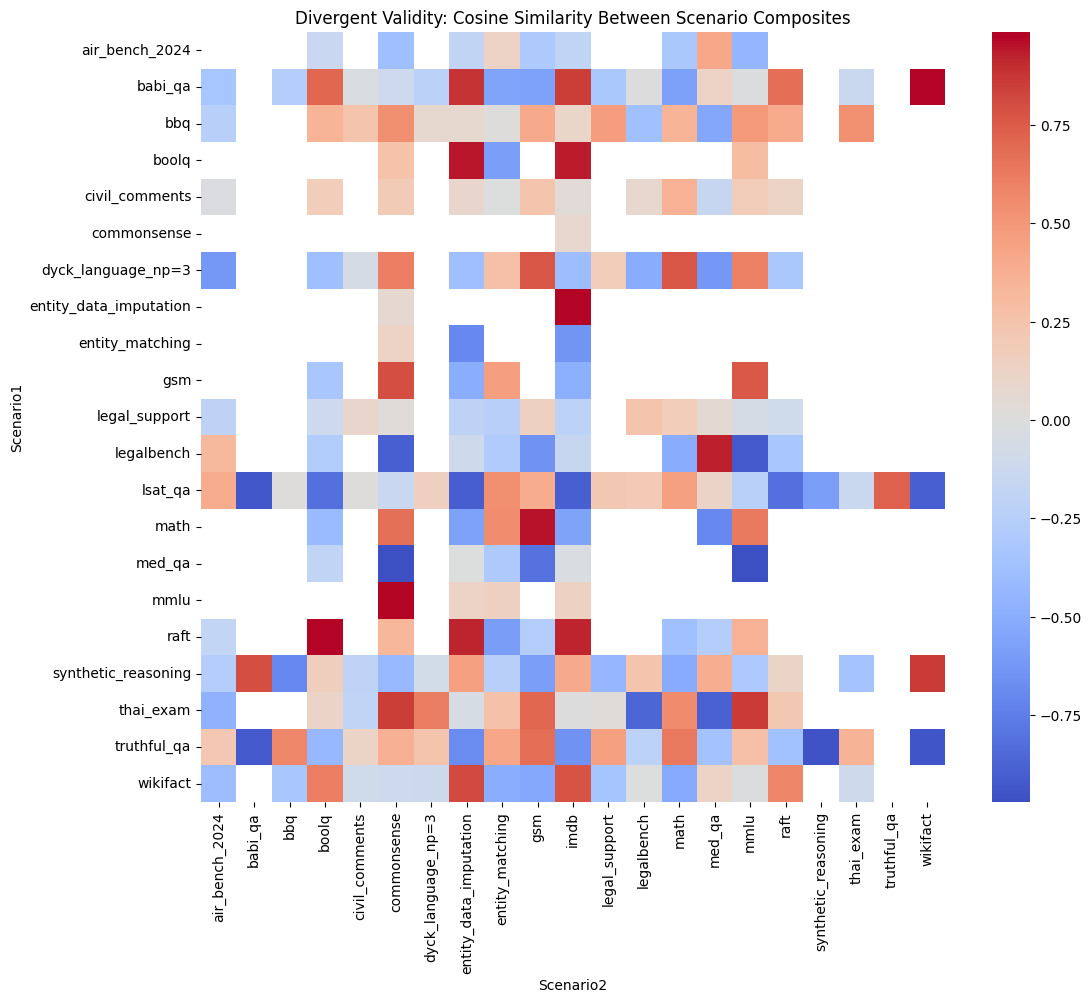

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from scipy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# Utilities
# ================================================================

def reference_composite(a_sub):
    """Compute dominant eigenvector (reference composite) for a scenario."""
    _, _, vh = svd(a_sub, full_matrices=False)
    return vh[0]

def evaluate_all_scenarios(a_df):
    """
    Evaluate convergent + divergent validity for all scenarios in a_df index.
    
    Parameters:
        a_df (pd.DataFrame): (items x dimensions) discrimination matrix
                             index must contain "scenario" level
    
    Returns:
        convergent_df (pd.DataFrame): avg alignment per scenario
        divergent_df (pd.DataFrame): cosine similarity between scenario composites
    """
    # Normalize item vectors
    a_norm = normalize(a_df.values, axis=1)
    a_norm_df = pd.DataFrame(a_norm, index=a_df.index, columns=a_df.columns)

    # Collect scenarios
    scenarios = a_df.index.get_level_values("scenario").unique()

    convergent_results = {}
    construct_vectors = {}

    for scen in scenarios:
        items = a_df.index[a_df.index.get_level_values("scenario") == scen].tolist()
        sub = a_norm_df.loc[items].values
        comp = reference_composite(sub)

        construct_vectors[scen] = comp

        # Compute cosine similarity of each item to composite
        sims = sub @ comp / (np.linalg.norm(comp) + 1e-9)
        convergent_results[scen] = sims.mean()

    convergent_df = pd.DataFrame.from_dict(convergent_results, orient="index", columns=["AvgAlignment"])

    # Divergent validity (pairwise cosines)
    divergent_results = {}
    scenarios = list(construct_vectors.keys())

    for i in range(len(scenarios)):
        for j in range(i + 1, len(scenarios)):
            s1, s2 = scenarios[i], scenarios[j]
            v1, v2 = construct_vectors[s1], construct_vectors[s2]
            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
            divergent_results[(s1, s2)] = cos_sim

    divergent_series = pd.Series(divergent_results)
    divergent_series.index = pd.MultiIndex.from_tuples(divergent_series.index, names=["Scenario1", "Scenario2"])
    divergent_df = divergent_series.unstack()

    return convergent_df, divergent_df

# ================================================================
# Run full evaluation
# ================================================================

convergent_df, divergent_df = evaluate_all_scenarios(a_df)

print("\nConvergent validity (avg cosine similarity per scenario):")
print(convergent_df.sort_values("AvgAlignment", ascending=False).round(3))

print("\nDivergent validity (cosine similarity between scenario composites):")
print(divergent_df.round(3).fillna(""))

# ================================================================
# Heatmap visualization
# ================================================================

plt.figure(figsize=(12,10))
sns.heatmap(divergent_df.astype(float), cmap="coolwarm", center=0, annot=False)
plt.title("Divergent Validity: Cosine Similarity Between Scenario Composites")
plt.show()


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_7592/1168716485.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


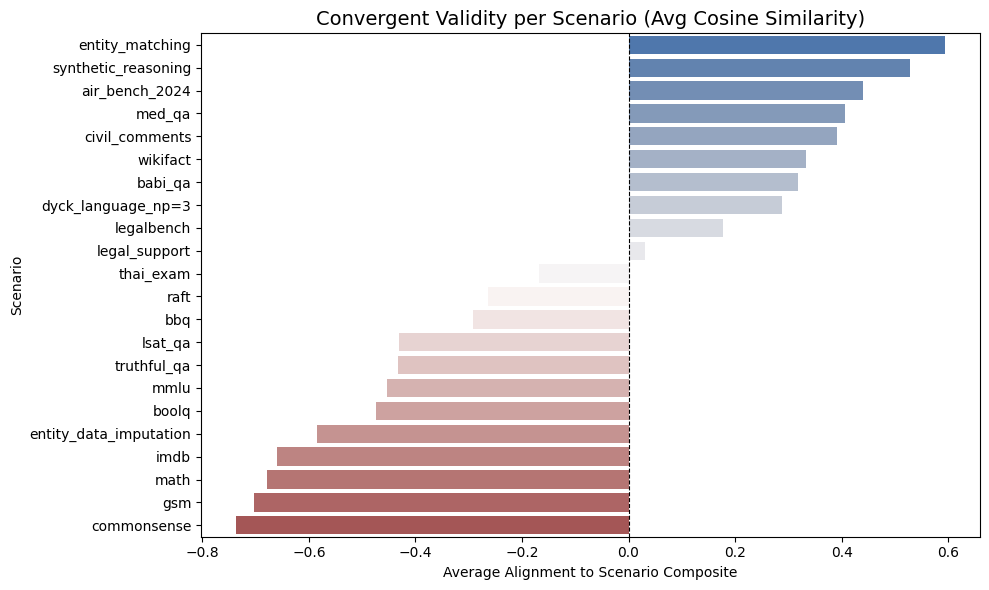

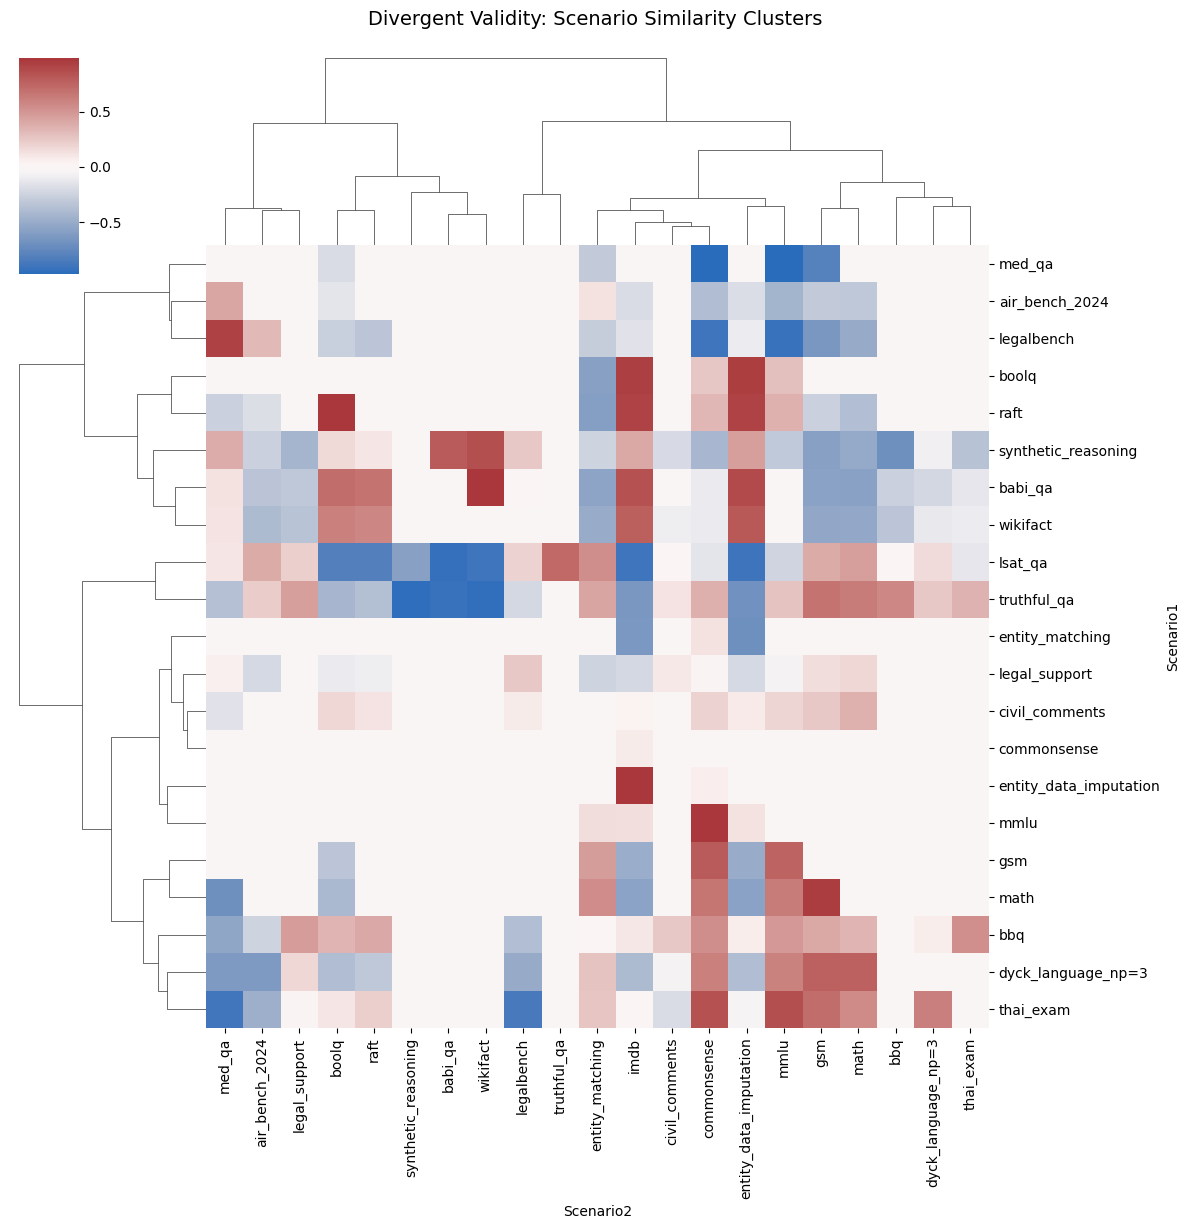

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram

# ================================================================
# 1. Convergent validity bar plot
# ================================================================

plt.figure(figsize=(10,6))
convergent_sorted = convergent_df.sort_values("AvgAlignment", ascending=False)
sns.barplot(
    x="AvgAlignment", 
    y=convergent_sorted.index, 
    data=convergent_sorted, 
    palette="vlag"
)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Convergent Validity per Scenario (Avg Cosine Similarity)", fontsize=14)
plt.xlabel("Average Alignment to Scenario Composite")
plt.ylabel("Scenario")
plt.tight_layout()
plt.show()

# ================================================================
# 2. Divergent validity heatmap with hierarchical clustering
# ================================================================

# Fill NaN (diagonal) with 0 for clustering purposes
divergent_matrix = divergent_df.fillna(0).astype(float)

# Hierarchical clustering
linkage_result = linkage(divergent_matrix, method="ward")

# Heatmap with clustering
sns.clustermap(
    divergent_matrix, 
    row_linkage=linkage_result, 
    col_linkage=linkage_result,
    cmap="vlag", 
    center=0, 
    figsize=(12,12)
)
plt.ylabel('')
plt.xlabel('')
plt.suptitle("Divergent Validity: Scenario Similarity Clusters", y=1.02, fontsize=14)
plt.show()


In [51]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Fill NaN with 0
divergent_matrix = divergent_df.fillna(0).astype(float)

# Ward linkage on scenario composites
linkage_result = linkage(divergent_matrix, method="ward")

# Auto-select number of clusters using distance threshold
max_d = 5.0   # <-- tweak this (smaller = more clusters, larger = fewer)
cluster_labels = fcluster(linkage_result, max_d, criterion="distance")

scenario_clusters = pd.DataFrame({
    "Scenario": divergent_matrix.index,
    "Cluster": cluster_labels
}).sort_values("Cluster")

print("\nScenario Clusters:")
print(scenario_clusters.groupby("Cluster")["Scenario"].apply(list))



Scenario Clusters:
Cluster
1                                                                           [air_bench_2024, synthetic_reasoning, raft, med_qa, legalbench, wikifact, boolq, babi_qa]
2    [dyck_language_np=3, entity_data_imputation, entity_matching, gsm, truthful_qa, civil_comments, lsat_qa, math, mmlu, bbq, thai_exam, commonsense, legal_support]
Name: Scenario, dtype: object


In [56]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Normalize item discrimination vectors
a_norm = normalize(a_df.values, axis=1)

# Try clustering items into k groups (start with k=19 or test a range)
k = 19  # adjust
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
item_labels = kmeans.fit_predict(a_norm)

# Map items to clusters
item_clusters = pd.DataFrame({
    "Item": a_df.index,
    "Cluster": item_labels
})

print("\nItem counts per cluster:")
print(item_clusters["Cluster"].value_counts())



Item counts per cluster:
Cluster
8     7772
17    6494
4     5655
6     5024
1     4620
10    4402
7     4298
2     4269
0     3981
12    3840
13    3750
16    3570
18    3506
3     3444
11    3244
14    3024
9     2763
15    2687
5     2369
Name: count, dtype: int64


In [57]:
def evaluate_clusters(a_df, construct_map):
    """
    Evaluate convergent + divergent validity given a construct_map.
    
    Parameters:
        a_df (pd.DataFrame): (items x dimensions) discrimination matrix
        construct_map (dict): {cluster_name: [item_ids]}
    
    Returns:
        convergent_df (pd.DataFrame)
        divergent_df (pd.DataFrame)
    """
    from sklearn.preprocessing import normalize
    from scipy.linalg import svd
    import numpy as np
    import pandas as pd

    def reference_composite(a_sub):
        _, _, vh = svd(a_sub, full_matrices=False)
        return vh[0]

    # Normalize item vectors
    a_norm = normalize(a_df.values, axis=1)
    a_norm_df = pd.DataFrame(a_norm, index=a_df.index, columns=a_df.columns)

    convergent_results = {}
    construct_vectors = {}

    for cluster, items in construct_map.items():
        sub = a_norm_df.loc[items].values
        comp = reference_composite(sub)

        construct_vectors[cluster] = comp

        sims = sub @ comp / (np.linalg.norm(comp) + 1e-9)
        convergent_results[cluster] = sims.mean()

    convergent_df = pd.DataFrame.from_dict(convergent_results, orient="index", columns=["AvgAlignment"])

    # Divergent validity
    divergent_results = {}
    clusters = list(construct_vectors.keys())

    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            c1, c2 = clusters[i], clusters[j]
            v1, v2 = construct_vectors[c1], construct_vectors[c2]
            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
            divergent_results[(c1, c2)] = cos_sim

    divergent_series = pd.Series(divergent_results)
    divergent_series.index = pd.MultiIndex.from_tuples(divergent_series.index, names=["Cluster1", "Cluster2"])
    divergent_df = divergent_series.unstack()

    return convergent_df, divergent_df

convergent_items, divergent_items = evaluate_clusters(a_df, construct_map)

print("\nConvergent validity (item clusters):")
print(convergent_items.sort_values("AvgAlignment", ascending=False))

print("\nDivergent validity (item clusters):")
print(divergent_items.round(3).fillna(""))



Convergent validity (item clusters):
            AvgAlignment
Cluster_1       0.770510
Cluster_7       0.755355
Cluster_5       0.747064
Cluster_4       0.726256
Cluster_12      0.603096
Cluster_0      -0.541544
Cluster_9      -0.606479
Cluster_3      -0.620285
Cluster_2      -0.651040
Cluster_13     -0.693670
Cluster_14     -0.718288
Cluster_8      -0.726859
Cluster_10     -0.749230
Cluster_11     -0.778801
Cluster_6      -0.800871

Divergent validity (item clusters):
Cluster2   Cluster_1 Cluster_10 Cluster_11 Cluster_12 Cluster_13  Cluster_14  \
Cluster1                                                                       
Cluster_0     -0.055      0.021      -0.03       0.32     -0.431      -0.472   
Cluster_1                -0.714     -0.547      0.039      0.316       0.092   
Cluster_10                           0.706     -0.133     -0.215      -0.011   
Cluster_11                                     -0.042      0.168      -0.254   
Cluster_12                                   

In [64]:
# Compact run: PCA -> GMM k-search -> weighted convergent validity diagnostics
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd

# prepare
a_norm = normalize(a_df.values, axis=1)
pca = PCA(n_components=19, random_state=42)
a_pca = pca.fit_transform(a_norm)
def evaluate_gmm_k_range(X, k_range):
    results = {}
    for k in k_range:
        print("Fitting GMM k=",k)
        g = GaussianMixture(n_components=k, covariance_type='diag', random_state=42, n_init=3)
        g.fit(X)
        probs = g.predict_proba(X)
        avg_conf = probs.max(axis=1).mean()
        # centroids in original 19D (weighted)
        centroids = (probs.T @ a_df.values) / probs.sum(axis=0)[:,None]
        # normalized and weighted avg alignment:
        norm_cent = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True)+1e-9)
        norm_items = a_df.values / (np.linalg.norm(a_df.values, axis=1, keepdims=True)+1e-9)
        cos_mat = norm_items @ norm_cent.T
        weighted_alignment = (cos_mat * probs).sum(axis=0) / probs.sum(axis=0)
        mean_weighted_alignment = weighted_alignment.mean()
        results[k] = {
            'gmm': g, 'probs': probs,
            'avg_confidence': avg_conf,
            'mean_weighted_alignment': float(mean_weighted_alignment),
            'cluster_sizes': list((probs.argmax(axis=1)).tolist()).count
        }
        print("  avg_conf=",avg_conf, " mean_weighted_alignment=", mean_weighted_alignment)
    return results

k_range = range(10,22)
gmm_results = evaluate_gmm_k_range(a_pca, k_range)
# pick best_k by whichever metric you prefer (avg_confidence or mean_weighted_alignment)


Fitting GMM k= 10
  avg_conf= 0.8711785406315946  mean_weighted_alignment= 0.6816069586303444
Fitting GMM k= 11
  avg_conf= 0.8769759462972155  mean_weighted_alignment= 0.700784110337559
Fitting GMM k= 12
  avg_conf= 0.8716204592216246  mean_weighted_alignment= 0.6977260196405579
Fitting GMM k= 13
  avg_conf= 0.8602975899398494  mean_weighted_alignment= 0.6988560257836999
Fitting GMM k= 14
  avg_conf= 0.8518422955689277  mean_weighted_alignment= 0.692854049703611
Fitting GMM k= 15
  avg_conf= 0.8397764054372011  mean_weighted_alignment= 0.6867508238234119
Fitting GMM k= 16
  avg_conf= 0.8384540099640686  mean_weighted_alignment= 0.6973899441382104
Fitting GMM k= 17
  avg_conf= 0.8253025148077769  mean_weighted_alignment= 0.7039816641014165
Fitting GMM k= 18
  avg_conf= 0.8044560025534095  mean_weighted_alignment= 0.6784452873408958
Fitting GMM k= 19
  avg_conf= 0.812279373118306  mean_weighted_alignment= 0.6899481861598409
Fitting GMM k= 20
  avg_conf= 0.8165205289644175  mean_weighted

In [65]:
from sklearn.mixture import GaussianMixture

best_k = 11  # or 10, based on your results

# Fit final GMM
gmm = GaussianMixture(n_components=best_k, covariance_type='diag', random_state=42, n_init=3)
gmm.fit(a_pca)

# Soft cluster assignments
probs = gmm.predict_proba(a_pca)   # (n_items x best_k)
labels = probs.argmax(axis=1)      # hard cluster labels


centroids = (probs.T @ a_df.values) / probs.sum(axis=0)[:,None]
norm_cent = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True)+1e-9)
divergent = norm_cent @ norm_cent.T
divergent_df = pd.DataFrame(divergent, 
                            index=[f"Cluster_{i}" for i in range(centroids.shape[0])],
                            columns=[f"Cluster_{i}" for i in range(centroids.shape[0])])
print(divergent_df.round(3))


            Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5  \
Cluster_0       1.000     -0.269     -0.553     -0.956     -0.004      0.409   
Cluster_1      -0.269      1.000      0.190      0.427      0.161      0.463   
Cluster_2      -0.553      0.190      1.000      0.482     -0.167      0.080   
Cluster_3      -0.956      0.427      0.482      1.000      0.067     -0.205   
Cluster_4      -0.004      0.161     -0.167      0.067      1.000      0.140   
Cluster_5       0.409      0.463      0.080     -0.205      0.140      1.000   
Cluster_6      -0.356     -0.119      0.366      0.399      0.284      0.253   
Cluster_7      -0.427      0.008      0.939      0.300     -0.056     -0.030   
Cluster_8       0.049     -0.916      0.025     -0.187      0.025     -0.390   
Cluster_9       0.644      0.076      0.249     -0.612     -0.136      0.683   
Cluster_10      0.500     -0.046     -0.110     -0.432      0.034      0.450   

            Cluster_6  Cluster_7  Clust

In [67]:
# For each scenario, compute avg membership distribution across clusters
scenarios = a_df.index.get_level_values("scenario")
scenario_dist = pd.DataFrame(
    0.0, 
    index=scenarios.unique(), 
    columns=[f"Cluster_{i}" for i in range(best_k)]
)

for scen in scenarios.unique():
    idx = np.where(scenarios == scen)[0]
    scenario_dist.loc[scen] = probs[idx].mean(axis=0)

print(scenario_dist.sort_index())


                        Cluster_0     Cluster_1     Cluster_2  Cluster_3  \
scenario                                                                   
air_bench_2024           0.108428  1.543611e-02  1.845941e-02   0.017975   
babi_qa                  0.005345  4.510872e-02  2.141697e-03   0.016906   
bbq                      0.001021  4.615100e-03  1.468908e-03   0.009287   
boolq                    0.002566  3.520462e-01  1.401205e-03   0.023671   
civil_comments           0.276765  1.111536e-02  3.433226e-04   0.120948   
commonsense              0.006367  1.314028e-07  5.059480e-01   0.019077   
dyck_language_np=3       0.001800  1.571588e-02  2.041408e-08   0.000393   
entity_data_imputation   0.002396  6.411787e-01  1.614479e-03   0.007583   
entity_matching          0.001738  4.277956e-01  1.114311e-03   0.004973   
gsm                      0.006181  7.707439e-04  1.188535e-01   0.031094   
imdb                     0.001172  6.272625e-01  4.638529e-04   0.008892   
legal_suppor

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram

# ================================================================
# 1. Convergent validity (bar plot per cluster)
# ================================================================
centroids = (probs.T @ a_df.values) / probs.sum(axis=0)[:, None]
norm_cent = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9)
norm_items = a_df.values / (np.linalg.norm(a_df.values, axis=1, keepdims=True) + 1e-9)

cos_mat = norm_items @ norm_cent.T
weighted_alignment = (cos_mat * probs).sum(axis=0) / probs.sum(axis=0)

convergent_df = pd.DataFrame({
    "Cluster": [f"Cluster_{i}" for i in range(best_k)],
    "AvgAlignment": weighted_alignment
}).sort_values("AvgAlignment", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=convergent_df, x="Cluster", y="AvgAlignment", palette="viridis")
plt.axhline(0, color="black", linestyle="--")
plt.title("Convergent Validity per Cluster", fontsize=14)
plt.ylabel("Average Alignment (cosine)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("convergent_validity.png", dpi=300)
plt.close()

# ================================================================
# 2. Divergent validity (heatmap with hierarchical clustering)
# ================================================================
divergent = norm_cent @ norm_cent.T
divergent_df = pd.DataFrame(divergent,
    index=[f"Cluster_{i}" for i in range(best_k)],
    columns=[f"Cluster_{i}" for i in range(best_k)]
)

# Cluster order using hierarchical clustering
linkage_result = linkage(divergent_df, method="ward")
sns.clustermap(divergent_df, cmap="coolwarm", center=0,
               row_linkage=linkage_result, col_linkage=linkage_result,
               linewidths=0.5, figsize=(10,8))
plt.suptitle("Divergent Validity (Cluster Similarities)", fontsize=14, y=1.02)
plt.savefig("divergent_validity.png", dpi=300)
plt.close()

# ================================================================
# 3. Scenario–cluster heatmap
# ================================================================
scenarios = a_df.index.get_level_values("scenario")
scenario_dist = pd.DataFrame(
    0.0,
    index=scenarios.unique(),
    columns=[f"Cluster_{i}" for i in range(best_k)]
)

for scen in scenarios.unique():
    idx = np.where(scenarios == scen)[0]
    scenario_dist.loc[scen] = probs[idx].mean(axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(scenario_dist, cmap="YlGnBu", cbar_kws={"label": "Avg Membership"})
plt.title("Scenario–Cluster Mapping", fontsize=14)
plt.ylabel("Scenario")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig("scenario_cluster_mapping.png", dpi=300)
plt.close()

print("✅ Figures saved: convergent_validity.png, divergent_validity.png, scenario_cluster_mapping.png")


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_7592/2594167744.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=convergent_df, x="Cluster", y="AvgAlignment", palette="viridis")


✅ Figures saved: convergent_validity.png, divergent_validity.png, scenario_cluster_mapping.png


In [69]:
# ================================================================
# 4. Cluster Profiles across 19 latent dimensions
# ================================================================
# Reuse centroids (cluster x 19)
centroids = (probs.T @ a_df.values) / probs.sum(axis=0)[:, None]

# Normalize each centroid vector for comparability
centroid_df = pd.DataFrame(
    centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9),
    index=[f"Cluster_{i}" for i in range(best_k)],
    columns=[f"Dim_{j}" for j in range(a_df.shape[1])]
)

plt.figure(figsize=(14,8))
sns.heatmap(centroid_df, cmap="coolwarm", center=0, cbar_kws={"label": "Normalized Loading"})
plt.title("Cluster Profiles across 19 MIRT Dimensions", fontsize=14)
plt.xlabel("MIRT Dimension")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=300)
plt.close()

print("✅ Figure saved: cluster_profiles.png")


✅ Figure saved: cluster_profiles.png


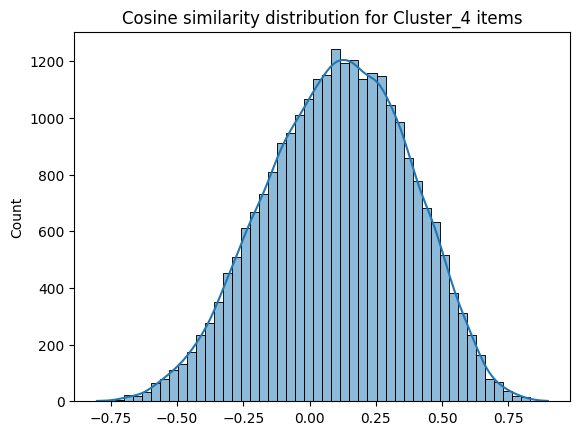

In [70]:
idx = (labels == 4)  # items in Cluster 4
sims = cos_mat[idx, 4]
sns.histplot(sims, bins=50, kde=True)
plt.title("Cosine similarity distribution for Cluster_4 items")
plt.show()


In [72]:
from sklearn.mixture import GaussianMixture
sub_data = a_pca[labels == 4]   # items from cluster 4 in PCA space
sub_gmm = GaussianMixture(n_components=3, random_state=42).fit(sub_data)
sub_labels = sub_gmm.predict(sub_data)
sub_labels

array([2, 1, 1, ..., 0, 0, 1], shape=(25389,))

⚠️ Cluster_4 flagged: size=0.32, AvgAlign=0.106

Exploring substructure for Cluster_4...


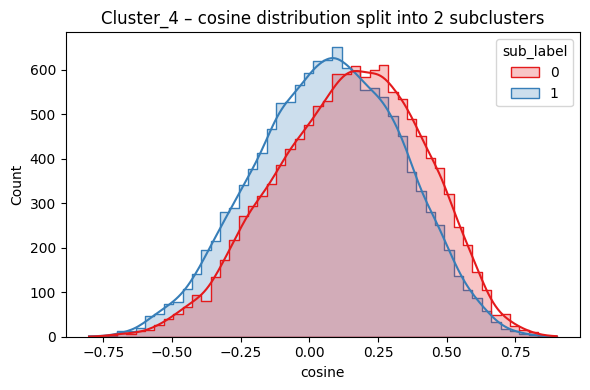

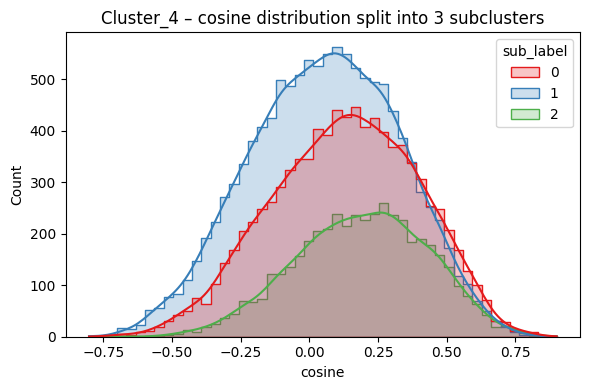

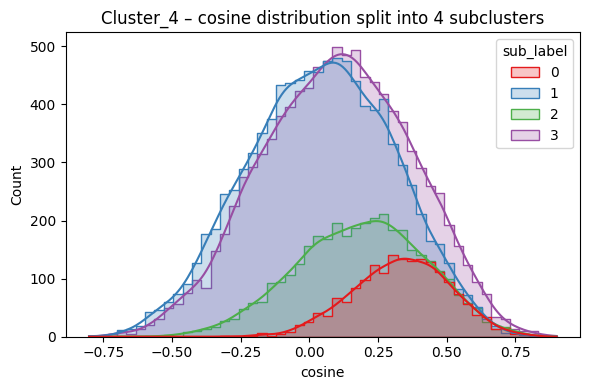

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def flag_composite_clusters(probs, cos_mat, labels, threshold_align=0.3, min_frac=0.2):
    n_items, n_clusters = probs.shape
    cluster_sizes = probs.argmax(axis=1)
    flagged = []

    for c in range(n_clusters):
        idx = (labels == c)
        frac = idx.mean()
        avg_align = (cos_mat[idx, c]).mean()

        if frac >= min_frac and avg_align < threshold_align:
            flagged.append((c, frac, avg_align))
            print(f"⚠️ Cluster_{c} flagged: size={frac:.2f}, AvgAlign={avg_align:.3f}")
    
    return flagged

# Run flagging
flagged = flag_composite_clusters(probs, cos_mat, labels, threshold_align=0.3, min_frac=0.2)

# ================================================================
# For each flagged cluster, try subclustering and plot distribution
# ================================================================
for (c, frac, avg_align) in flagged:
    print(f"\nExploring substructure for Cluster_{c}...")
    idx = (labels == c)
    sub_data = a_pca[idx]

    # Try splitting into 2–4 subclusters
    for k in [2,3,4]:
        gmm_sub = GaussianMixture(n_components=k, covariance_type="diag", random_state=42).fit(sub_data)
        sub_labels = gmm_sub.predict(sub_data)
        
        # Plot
        plt.figure(figsize=(6,4))
        # Prepare a DataFrame for long-form plotting
        import pandas as pd
        plot_df = pd.DataFrame({
            "cosine": cos_mat[idx, c],
            "sub_label": sub_labels
        })
        sns.histplot(data=plot_df, x="cosine", bins=50, kde=True, hue="sub_label", element="step", palette="Set1")
        plt.title(f"Cluster_{c} – cosine distribution split into {k} subclusters")
        plt.tight_layout()
        plt.show()
